# Data imputation

The data is heavely unbalanced, if the nulls are deleted some classes are not even represented. In order to solve this we've used data imputation


In [61]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
dataset = pd.read_csv("../datasets/thyroid0387_cleanded.data", sep = ";", index_col="Unnamed: 0")

In [63]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6547
hypothyroid               572
general_health            435
replacement_therapy       336
binding_protein           324
misc                      247
hyperthyroid              189
antithyroid_treatment      33
Name: count, dtype: int64

In [64]:
dataset.dropna()["diagnosis_group"].value_counts()

diagnosis_group
normal                 15
hypothyroid             2
general_health          1
replacement_therapy     1
Name: count, dtype: int64

# Imputation of NaNs

In [65]:
dataset.dtypes

age                            int64
on_thyroxine                    bool
query_on_thyroxine              bool
on_antithyroid_medication       bool
sick                            bool
pregnant                        bool
thyroid_surgery                 bool
I131_treatment                  bool
query_hypothyroid               bool
query_hyperthyroid              bool
lithium                         bool
goitre                          bool
tumor                           bool
hypopituitary                   bool
psych                           bool
diagnosis                     object
diagnosis_group               object
sex_M                           bool
TSH_value                    float64
T3_value                     float64
TT4_value                    float64
T4U_value                    float64
FTI_value                    float64
TBG_value                    float64
ref_STMW                        bool
ref_SVHC                        bool
ref_SVHD                        bool
r

In [66]:
x = dataset.drop(columns = ["diagnosis_group"])
y = dataset["diagnosis_group"]

In [67]:
numeric_col = x.select_dtypes(include = ["int64", "float64"]).columns
categoric_col = x.select_dtypes(exclude = ["int64", "float64"]).columns

In [68]:
# SimpleImputer can't handle the Bool type, parsing to Object
x[categoric_col] = x[categoric_col].astype("object")

In [69]:
numerical_imputer = IterativeImputer(random_state = 42)
categorical_imputer = SimpleImputer(strategy = "most_frequent")

In [70]:
processor = ColumnTransformer(
    transformers = [
        ("num", numerical_imputer, numeric_col),
        ("cat", categorical_imputer, categoric_col)
    ]
)

In [74]:
x[y == "binding_protein"]

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
33,71,True,False,False,False,False,False,False,False,False,...,126.0,1.38,91.0,NaN,False,False,False,False,False,True
94,66,True,False,False,False,False,False,False,False,False,...,81.0,1.29,63.0,NaN,False,False,False,False,False,True
97,56,True,False,False,False,False,False,False,False,False,...,87.0,1.30,67.0,NaN,False,False,False,False,False,True
117,83,False,False,False,False,False,False,False,False,False,...,144.0,1.44,100.0,NaN,False,False,False,False,False,True
131,40,False,False,False,False,False,False,True,False,False,...,112.0,0.83,135.0,NaN,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9095,43,False,False,False,False,False,False,False,False,False,...,46.0,0.64,72.0,NaN,False,False,False,False,False,True
9118,63,False,False,False,False,False,False,False,False,True,...,126.0,1.66,76.0,NaN,False,False,False,False,False,True
9158,64,False,False,False,False,False,False,False,True,False,...,44.0,0.53,83.0,NaN,False,False,False,False,False,True
9162,36,False,False,False,False,False,False,False,False,False,...,84.0,1.26,67.0,NaN,False,False,False,False,False,True


In [78]:
# ALTÍSSIM HACK ##############
index = x[y == "antithyroid_treatment"].index[0]
x.loc[index, "TBG_value"] = 22.5

index = x[y == "binding_protein"].index[0]
x.loc[index, "TBG_value"] = 22.5
##############################

x_imputed = x.copy()

for diagnosis in set(y):
    x_subset = x[y == diagnosis]

    print(diagnosis)
    
    # Fit and transform
    x_transformed = processor.fit_transform(x_subset)
    
    # Turn back into DataFrame with correct column names
    x_transformed_df = pd.DataFrame(x_transformed, 
                                    index=x_subset.index, 
                                    columns=numeric_col.tolist() + categoric_col.tolist())
    
    # Assign back
    x_imputed.loc[x_subset.index] = x_transformed_df

# x_imputed = processor.fit_transform(x)
# x_imputed = pd.DataFrame(x_imputed, columns = numeric_col.tolist() + categoric_col.tolist())

antithyroid_treatment
replacement_therapy
misc
hypothyroid
binding_protein
normal


C:\Users\arnau.metaute\AppData\Local\Temp\ipykernel_21236\4242642745.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[33.0 58.0 38.0 27.0 57.0 55.0 53.0 15.0 41.0 37.0 16.0 18.0 34.0 33.0
 50.0 62.0 42.0 50.0 33.0 66.0 26.0 20.0 73.0 33.0 46.0 64.0 68.0 21.0
 74.0 24.0 57.0 35.0 77.0]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_imputed.loc[x_subset.index] = x_transformed_df
C:\Users\arnau.metaute\AppData\Local\Temp\ipykernel_21236\4242642745.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[53.0 7.5 22.0 56.0 0.25 8.4 34.0 14.0 18.0 27.0 30.0 16.0 26.0 8.2 76.0
 6.5 7.2 5.5 2.3 2.7 1.1 3.2 2.4 8.799999 1.7 3.3 54.0 7.0 4.3 0.03
 16.799999 0.47 39.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  x_imputed.loc[x_subset.inde

general_health
hyperthyroid


c:\Users\arnau.metaute\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\arnau.metaute\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\arnau.metaute\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [79]:
x.head(10)

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,29,False,False,False,False,False,False,False,True,False,...,NaN,NaN,NaN,NaN,False,False,False,False,False,True
1,29,False,False,False,False,False,False,False,False,False,...,128.0,NaN,NaN,NaN,False,False,False,False,False,True
2,41,False,False,False,False,False,False,False,False,True,...,NaN,NaN,NaN,11.0,False,False,False,False,False,True
3,36,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,26.0,False,False,False,False,False,True
4,32,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,36.0,False,False,False,False,False,True
5,60,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,26.0,False,False,False,False,False,True
6,77,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,21.0,False,False,False,False,False,True
7,28,False,False,False,False,False,False,False,False,False,...,116.0,NaN,NaN,NaN,False,False,False,True,False,False
8,28,False,False,False,False,False,False,False,False,False,...,76.0,NaN,NaN,NaN,False,False,False,False,False,True
9,28,False,False,False,False,False,False,False,False,False,...,83.0,NaN,NaN,NaN,False,False,False,False,False,True


In [80]:
x_imputed.head(10)

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,29.0,False,False,False,False,False,False,False,True,False,...,105.957986,0.964407,110.901257,32.308245,False,False,False,False,False,True
1,29.0,False,False,False,False,False,False,False,False,False,...,128.0,0.972645,133.325191,21.728779,False,False,False,False,False,True
2,41.0,False,False,False,False,False,False,False,False,True,...,88.973106,0.77613,122.989623,11.0,False,False,False,False,False,True
3,36.0,False,False,False,False,False,False,False,False,False,...,107.249494,1.015283,107.444888,26.0,False,False,False,False,False,True
4,32.0,False,False,False,False,False,False,False,False,False,...,91.262932,0.818433,120.404426,36.0,False,False,False,False,False,True
5,60.0,False,False,False,False,False,False,False,False,False,...,106.154644,1.00319,108.300735,26.0,False,False,False,False,False,True
6,77.0,False,False,False,False,False,False,False,False,False,...,99.363027,0.915746,114.029105,21.0,False,False,False,False,False,True
7,28.0,False,False,False,False,False,False,False,False,False,...,116.0,0.973399,121.07676,31.041733,False,False,False,True,False,False
8,28.0,False,False,False,False,False,False,False,False,False,...,76.0,0.950587,80.38312,28.215963,False,False,False,False,False,True
9,28.0,False,False,False,False,False,False,False,False,False,...,83.0,0.953171,87.494761,22.940755,False,False,False,False,False,True


## Updating dataset

In [81]:
temp = pd.concat([x_imputed, y], axis = 1)

In [82]:
for col in dataset.columns:
    dataset[col] = temp[col]

In [83]:
dataset.dropna()["diagnosis_group"].value_counts()

diagnosis_group
normal                   6547
hypothyroid               572
general_health            435
replacement_therapy       336
binding_protein           324
misc                      247
hyperthyroid              189
antithyroid_treatment      33
Name: count, dtype: int64

In [84]:
dataset = dataset.dropna()

In [85]:
for col in numeric_col:
    dataset = dataset[dataset[col] >= 0]

In [86]:
def plot_univariate_distribution(df, column, bins=30):
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))

    sns.histplot(df[column].dropna(), kde=True, bins=bins, ax=axs[0], color="blue")
    axs[0].set_title(f"Histogram of {column}")
    
    sns.boxplot(x=df[column], ax=axs[1], color="orange")
    axs[1].set_title(f"Boxplot of {column}")
    
    plt.tight_layout()
    plt.show()

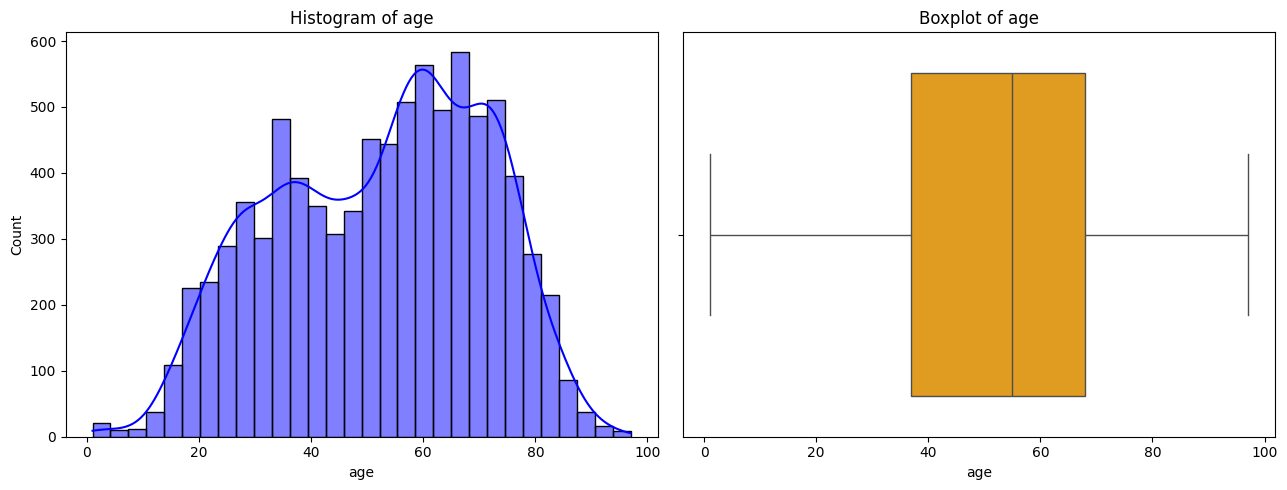

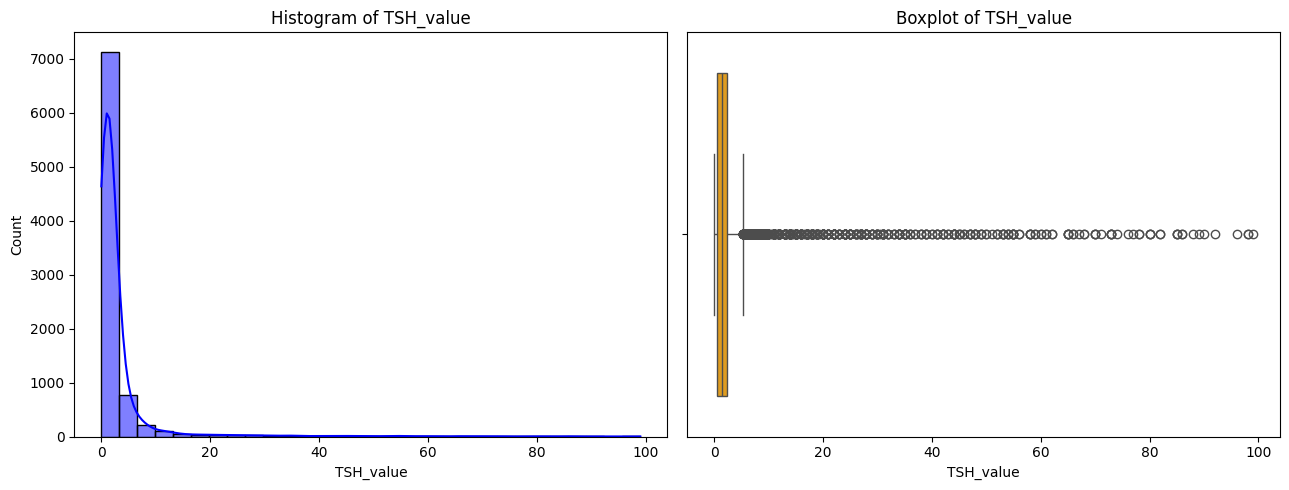

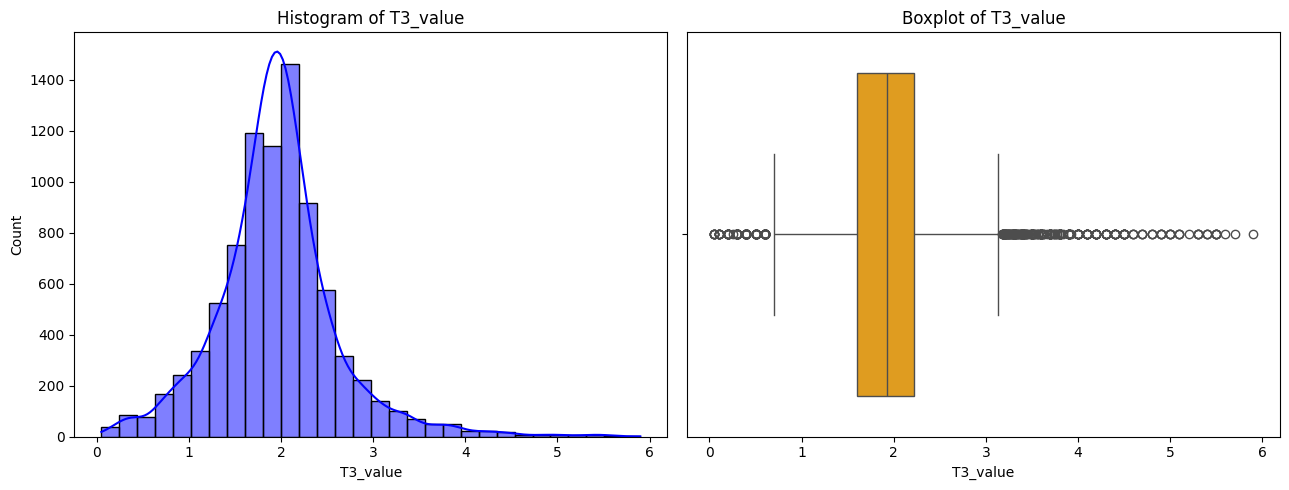

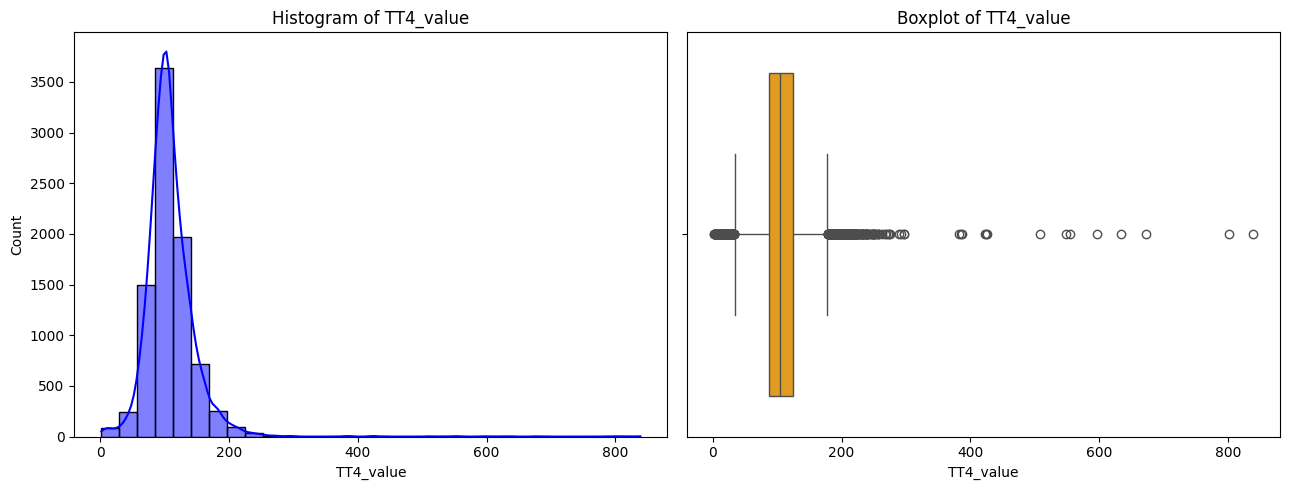

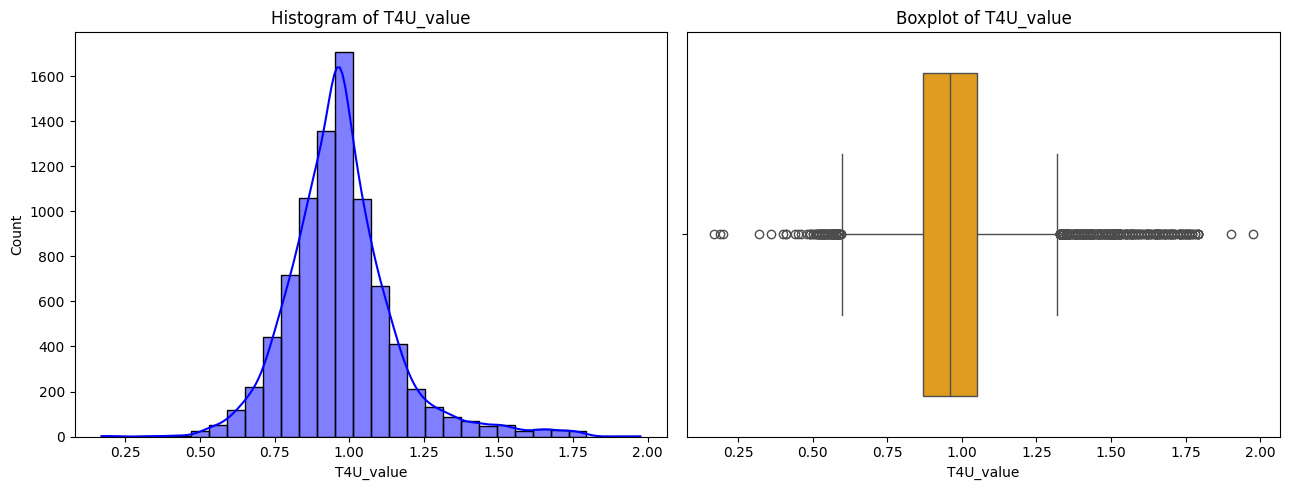

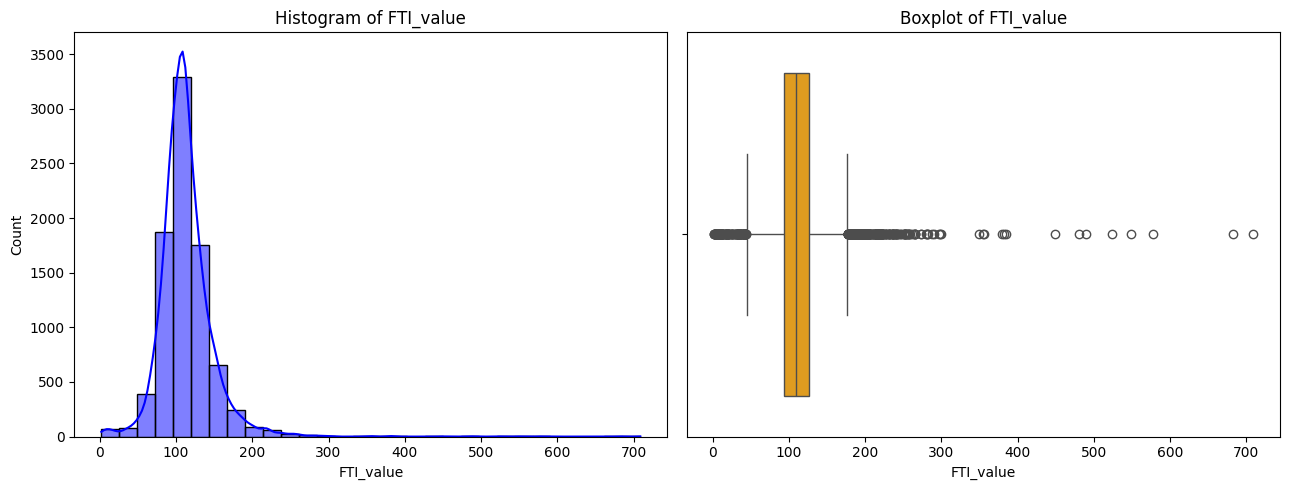

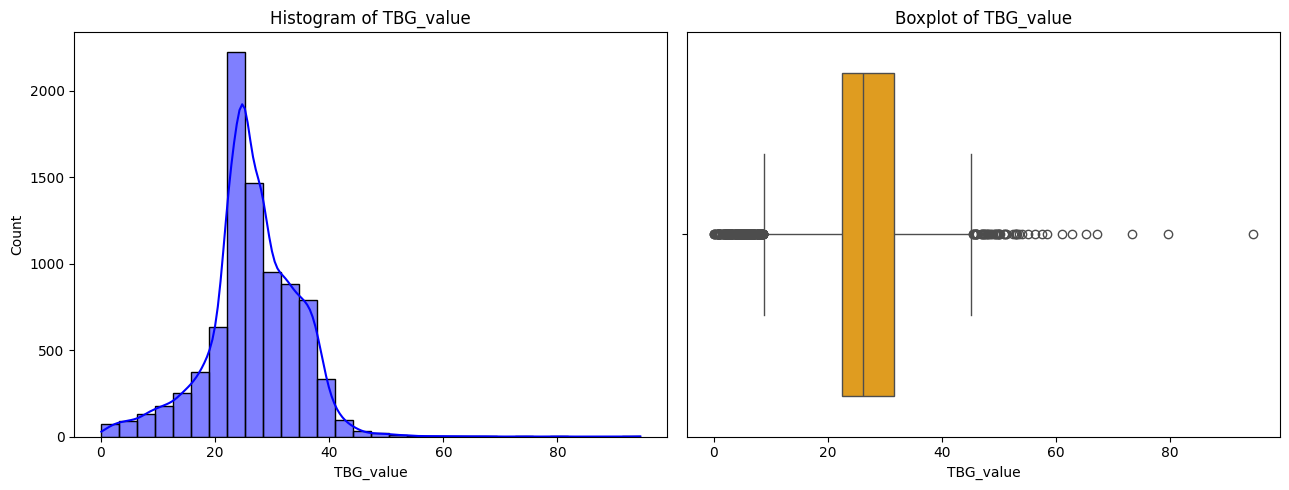

In [87]:
for col in numeric_col:
    plot_univariate_distribution(dataset, col)

In [88]:
dataset.to_csv("../datasets/thyroid0387_imputed.data", sep=";")